# Decoding Social Intent from Neural Oscillations

**Spectral analysis of calcium imaging reveals a theta-enriched neuron subpopulation that encodes social behavior**

Kaiwen Bian, Ketan Mittal, Anirudh Annabathula, Yixuan Xin  
Halıcıoğlu Data Science Institute & Department of Cognitive Science, UC San Diego  
COGS 118C · Winter 2026

---

## Abstract

Social behavior requires coordinated neural activity, yet whether spectral signatures of individual neurons can predict social state remains unclear. We analyzed calcium imaging recordings from mouse prefrontal cortex across 18 sessions, extracting frequency-band power features from 3,938 neurons. While theta-band (4–7 Hz) power increases during social interaction at the population level (Cohen’s d = 0.235, p < 0.001), classification using all neurons fails a permutation test. Spectral clustering reveals two subpopulations: a majority (70%) dominated by infraslow oscillations, and a minority (30%) enriched in delta and theta power. Only this minority subpopulation significantly classifies social vs. solo behavior (AUC = 0.570, permutation p = 0.020), using theta/delta ratio—not raw power—as its top feature. These results suggest that social coding is concentrated in a spectrally distinct neuronal minority.

---
## Introduction

Theta-band (4–7 Hz) oscillations in the prefrontal cortex track social behavior in mice. Kuga et al. (2022) showed this with electrophysiology and confirmed it causally via optogenetics, while Mohapatra et al. (2025) demonstrated that excess theta synchrony impairs social discrimination. But these findings come from local field potentials—a macroscopic signal. We asked: **can the same theta signatures be recovered from individual neurons using calcium imaging?**

Calcium imaging studies of social behavior in mPFC have revealed rich single-cell coding (Liang et al. 2018; Kingsbury et al. 2019; Frost, Haggart & Sohal 2021), but every study uses rate-based or correlation-based measures—none have examined frequency content. The technical challenge is real: GCaMP6s has a ~600 ms decay time, placing theta at the very edge of what calcium imaging can resolve.

We bridge this gap using data from the EDGE neuroscience course (Talmo Pereira and colleagues), applying spectral feature extraction—Welch PSD, band power, theta/delta ratio—to single-neuron calcium traces. Rather than asking *which neurons fire more*, we ask *which neurons oscillate differently*.

### Research Questions

1. **Band–Behavior Link** — Do specific frequency bands of the calcium signal differentiate social from solo epochs?
2. **Neuron–Band Heterogeneity** — Do neurons split into subpopulations with distinct spectral profiles?
3. **Subpopulation Classification** — Does a spectrally defined subpopulation drive behavior classification?

---
## 1. Setup & Data Loading

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from pathlib import Path

from scipy.signal import welch, detrend, butter, sosfiltfilt, hilbert
from scipy.stats import ranksums, mannwhitneyu, entropy
from scipy.ndimage import center_of_mass

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, accuracy_score

from tqdm import tqdm

# Project modules
from src.constants import (BEHAVIOR_FPS, IMAGING_FPS, FREQ_BANDS, BAND_COLORS,
                           ISO_COLORS, MIN_BOUT_S, PRE_S, POST_S)
from src.data import (download_data, load_entrances, load_behavior,
                      load_imaging, align_all_sessions, get_epoch_durations,
                      load_spatial_footprints)
from src.signal_processing import (bandpass_filter, compute_welch_psd,
                                   compute_band_powers, band_envelope)
from src.analysis import (extract_labeled_windows, bp_list_to_array, cohens_d,
                          compute_neuron_spectral_profiles, cluster_neurons,
                          extract_feature_matrix, run_classification,
                          run_permutation_test)
from src.visualization import shade_social, add_band_shading

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

BAND_NAMES = list(FREQ_BANDS.keys())
iso_colors = ISO_COLORS
print('All imports successful.')

All imports successful.


In [2]:
# Download data from Google Drive (skips if already present)
DATA_DIR = download_data()

# Load session metadata
entrances = load_entrances(DATA_DIR)
n_sessions = len(entrances)
print(f'Sessions: {n_sessions}')
print(f'Isolation conditions: {entrances["Isolation Length"].value_counts().to_dict()}')

  [skip] calcium.00.h5 (238.6 MB)
  [skip] social_bouts.00.h5 (0.5 MB)
  [skip] SI3_2022_Entrance_Frames.xlsx (0.0 MB)
  [skip] behavior_video.mp4 (37.6 MB)
  [skip] behavior_tracking.slp (10.1 MB)
Sessions: 18
Isolation conditions: {'24hr': 6, '7d': 6, 'GH (7d)': 3, 'GH (24hr)': 3}


In [3]:
# Load behavioral labels and calcium imaging
behavior = load_behavior(n_sessions, DATA_DIR)
imaging = load_imaging(n_sessions, DATA_DIR)

# Align behavior (25 fps) to calcium imaging (30 fps)
aligned_calcium, aligned_behavior, session_info, session_df = \
    align_all_sessions(imaging, behavior, entrances)

  Session  0:   7788 frames, 202 neurons, 260s, 38.9% social, GH (7d)
  Session  1:   8776 frames,  12 neurons, 293s, 41.5% social, GH (7d)
  Session  2:   8847 frames, 289 neurons, 295s, 16.3% social, GH (7d)
  Session  3:   8887 frames, 268 neurons, 296s, 25.3% social, 24hr
  Session  4:   8895 frames, 134 neurons, 296s, 30.4% social, 24hr
  Session  5:   8882 frames, 271 neurons, 296s, 38.0% social, 24hr
  Session  6:   8897 frames, 218 neurons, 297s, 21.6% social, 7d
  Session  7:   8872 frames, 207 neurons, 296s, 30.7% social, 7d
  Session  8:   8830 frames, 332 neurons, 294s, 32.5% social, 7d
  Session  9:   8882 frames, 396 neurons, 296s, 29.7% social, GH (24hr)
  Session 10:   8860 frames, 288 neurons, 295s, 24.1% social, GH (24hr)
  Session 11:   6544 frames,  96 neurons, 218s, 36.2% social, GH (24hr)
  Session 12:   8847 frames,  72 neurons, 295s, 25.1% social, 24hr
  Session 13:   8904 frames, 225 neurons, 297s, 28.0% social, 24hr
  Session 14:   8874 frames, 231 neurons, 29

In [4]:
# Dataset summary
total_neurons = sum(c.shape[1] for c in aligned_calcium)
total_frames = sum(c.shape[0] for c in aligned_calcium)
total_minutes = total_frames / IMAGING_FPS / 60

print(f'Total neurons: {total_neurons:,}')
print(f'Sessions used: {len(aligned_calcium)}')
print(f'Total recording time: {total_minutes:.1f} min')
print(f'Sampling rate: {IMAGING_FPS} Hz')

Total neurons: 3,938
Sessions used: 18
Total recording time: 86.7 min
Sampling rate: 30 Hz


In [5]:
# Pick example session closest to 30% social
ex = session_df['social_frac'].sub(0.3).abs().idxmin()
ex_cal = aligned_calcium[ex]
ex_beh = aligned_behavior[ex]
ex_info = session_info[ex]
t = np.arange(len(ex_cal)) / IMAGING_FPS

print(f'Example: session {ex_info["session_idx"]} | '
      f'{ex_info["n_neurons"]} neurons | {ex_info["duration_s"]:.0f}s | '
      f'{ex_info["social_frac"]*100:.1f}% social | {ex_info["isolation"]}')

Example: session 9 | 396 neurons | 296s | 29.7% social | GH (24hr)


---
## 2. The Neural Recording

While the mouse behaves, a miniature microscope images calcium fluorescence through a GRIN lens implanted in the prefrontal cortex. Neurons that fire produce transient increases in fluorescence (ΔF/F), giving us a continuous signal for each cell at 30 fps.

### Figure 4 — Raw Calcium Traces

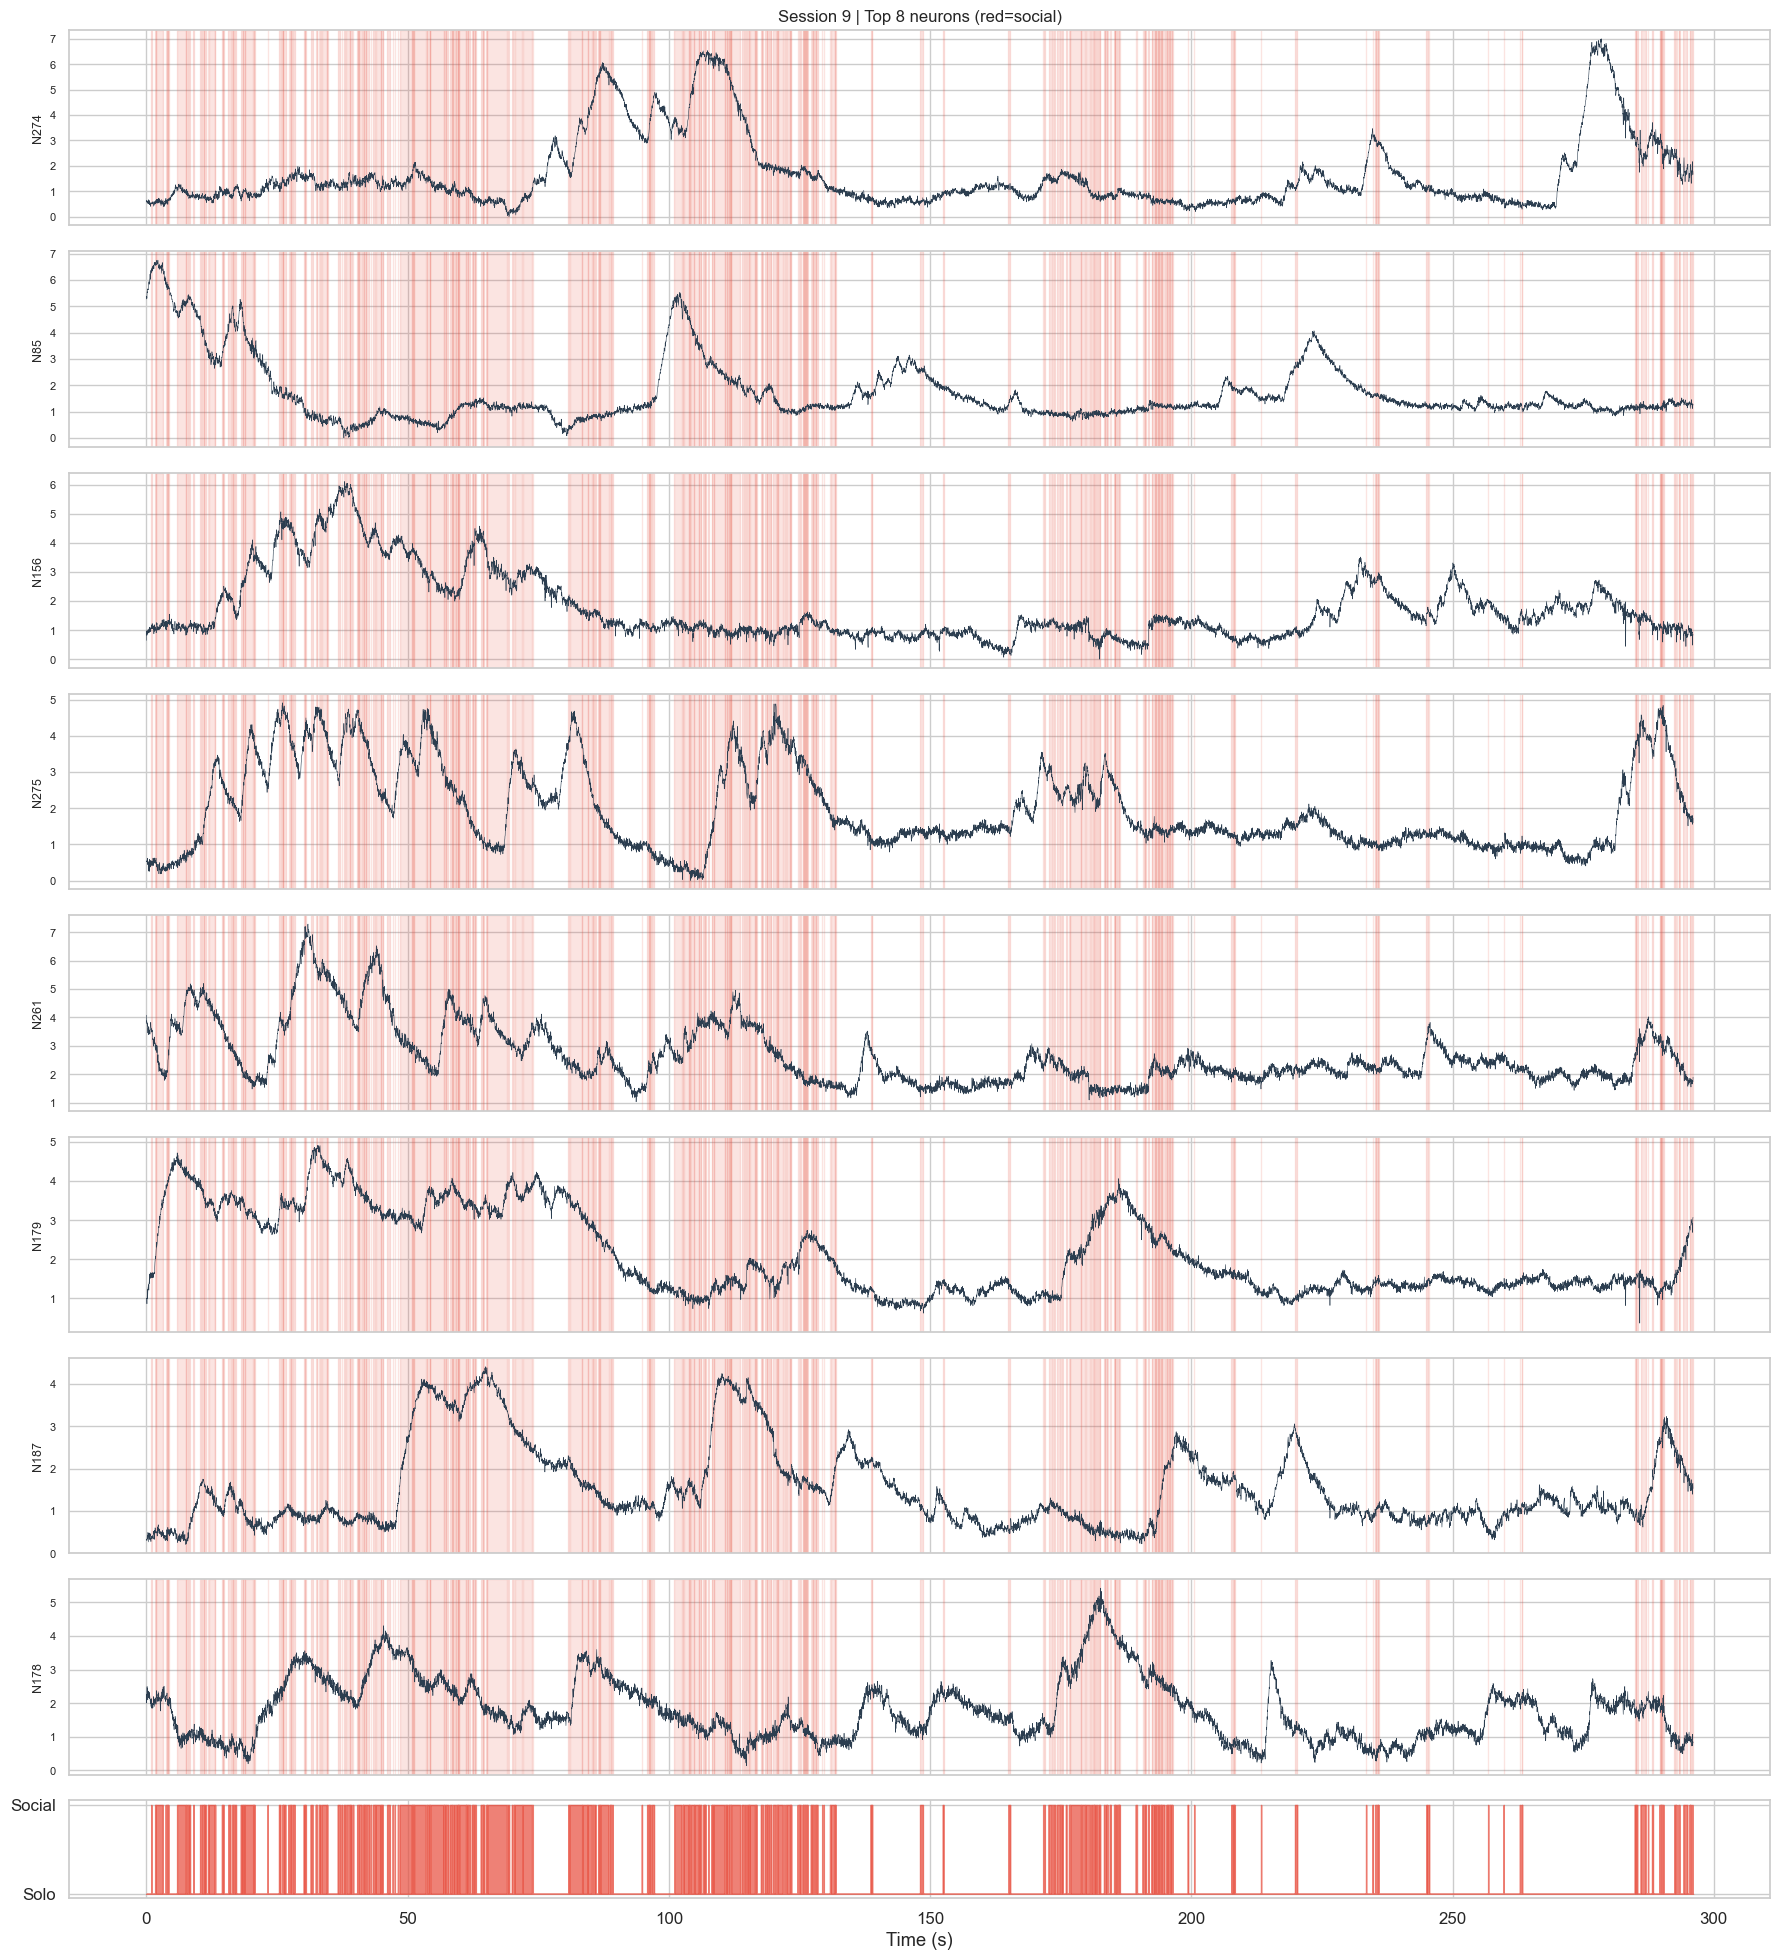

In [6]:
# Figure 4: Top active neuron traces with social epoch shading
n_show = 8
top_neurons = np.argsort(ex_cal.std(axis=0))[-n_show:][::-1]

fig, axes = plt.subplots(n_show+1, 1, figsize=(18, 2.2*(n_show+1)),
                         sharex=True,
                         gridspec_kw={'height_ratios': [1]*n_show + [0.5]})

for i, ni in enumerate(top_neurons):
    axes[i].plot(t, ex_cal[:, ni], lw=0.4, color='#2c3e50')
    shade_social(axes[i], ex_beh, t)
    axes[i].set_ylabel(f'N{ni}', fontsize=9)
    axes[i].tick_params(labelsize=8)

axes[-1].fill_between(t, ex_beh.astype(float), step='pre', alpha=0.7, color='#e74c3c')
axes[-1].set_yticks([0,1]); axes[-1].set_yticklabels(['Solo','Social'])
axes[-1].set_xlabel('Time (s)')
axes[0].set_title(f'Session {ex_info["session_idx"]} | Top {n_show} neurons (red=social)', fontsize=12)

plt.tight_layout(); plt.show()

---
## 3. Signal Properties: How Neurons Respond to Social Contact

Using Butterworth bandpass filters, we decompose each neuron's calcium trace into four frequency bands:

| Band | Range | Captures |
|------|-------|----------|
| **Infraslow** | 0.01–0.1 Hz | Very slow drifts |
| **Slow** | 0.1–1.0 Hz | Network-level synchronization |
| **Delta** | 1.0–4.0 Hz | Slow rhythmic activity |
| **Theta** | 4.0–7.0 Hz | Social behavior and attention |

### Figure 5 — Band Decomposition

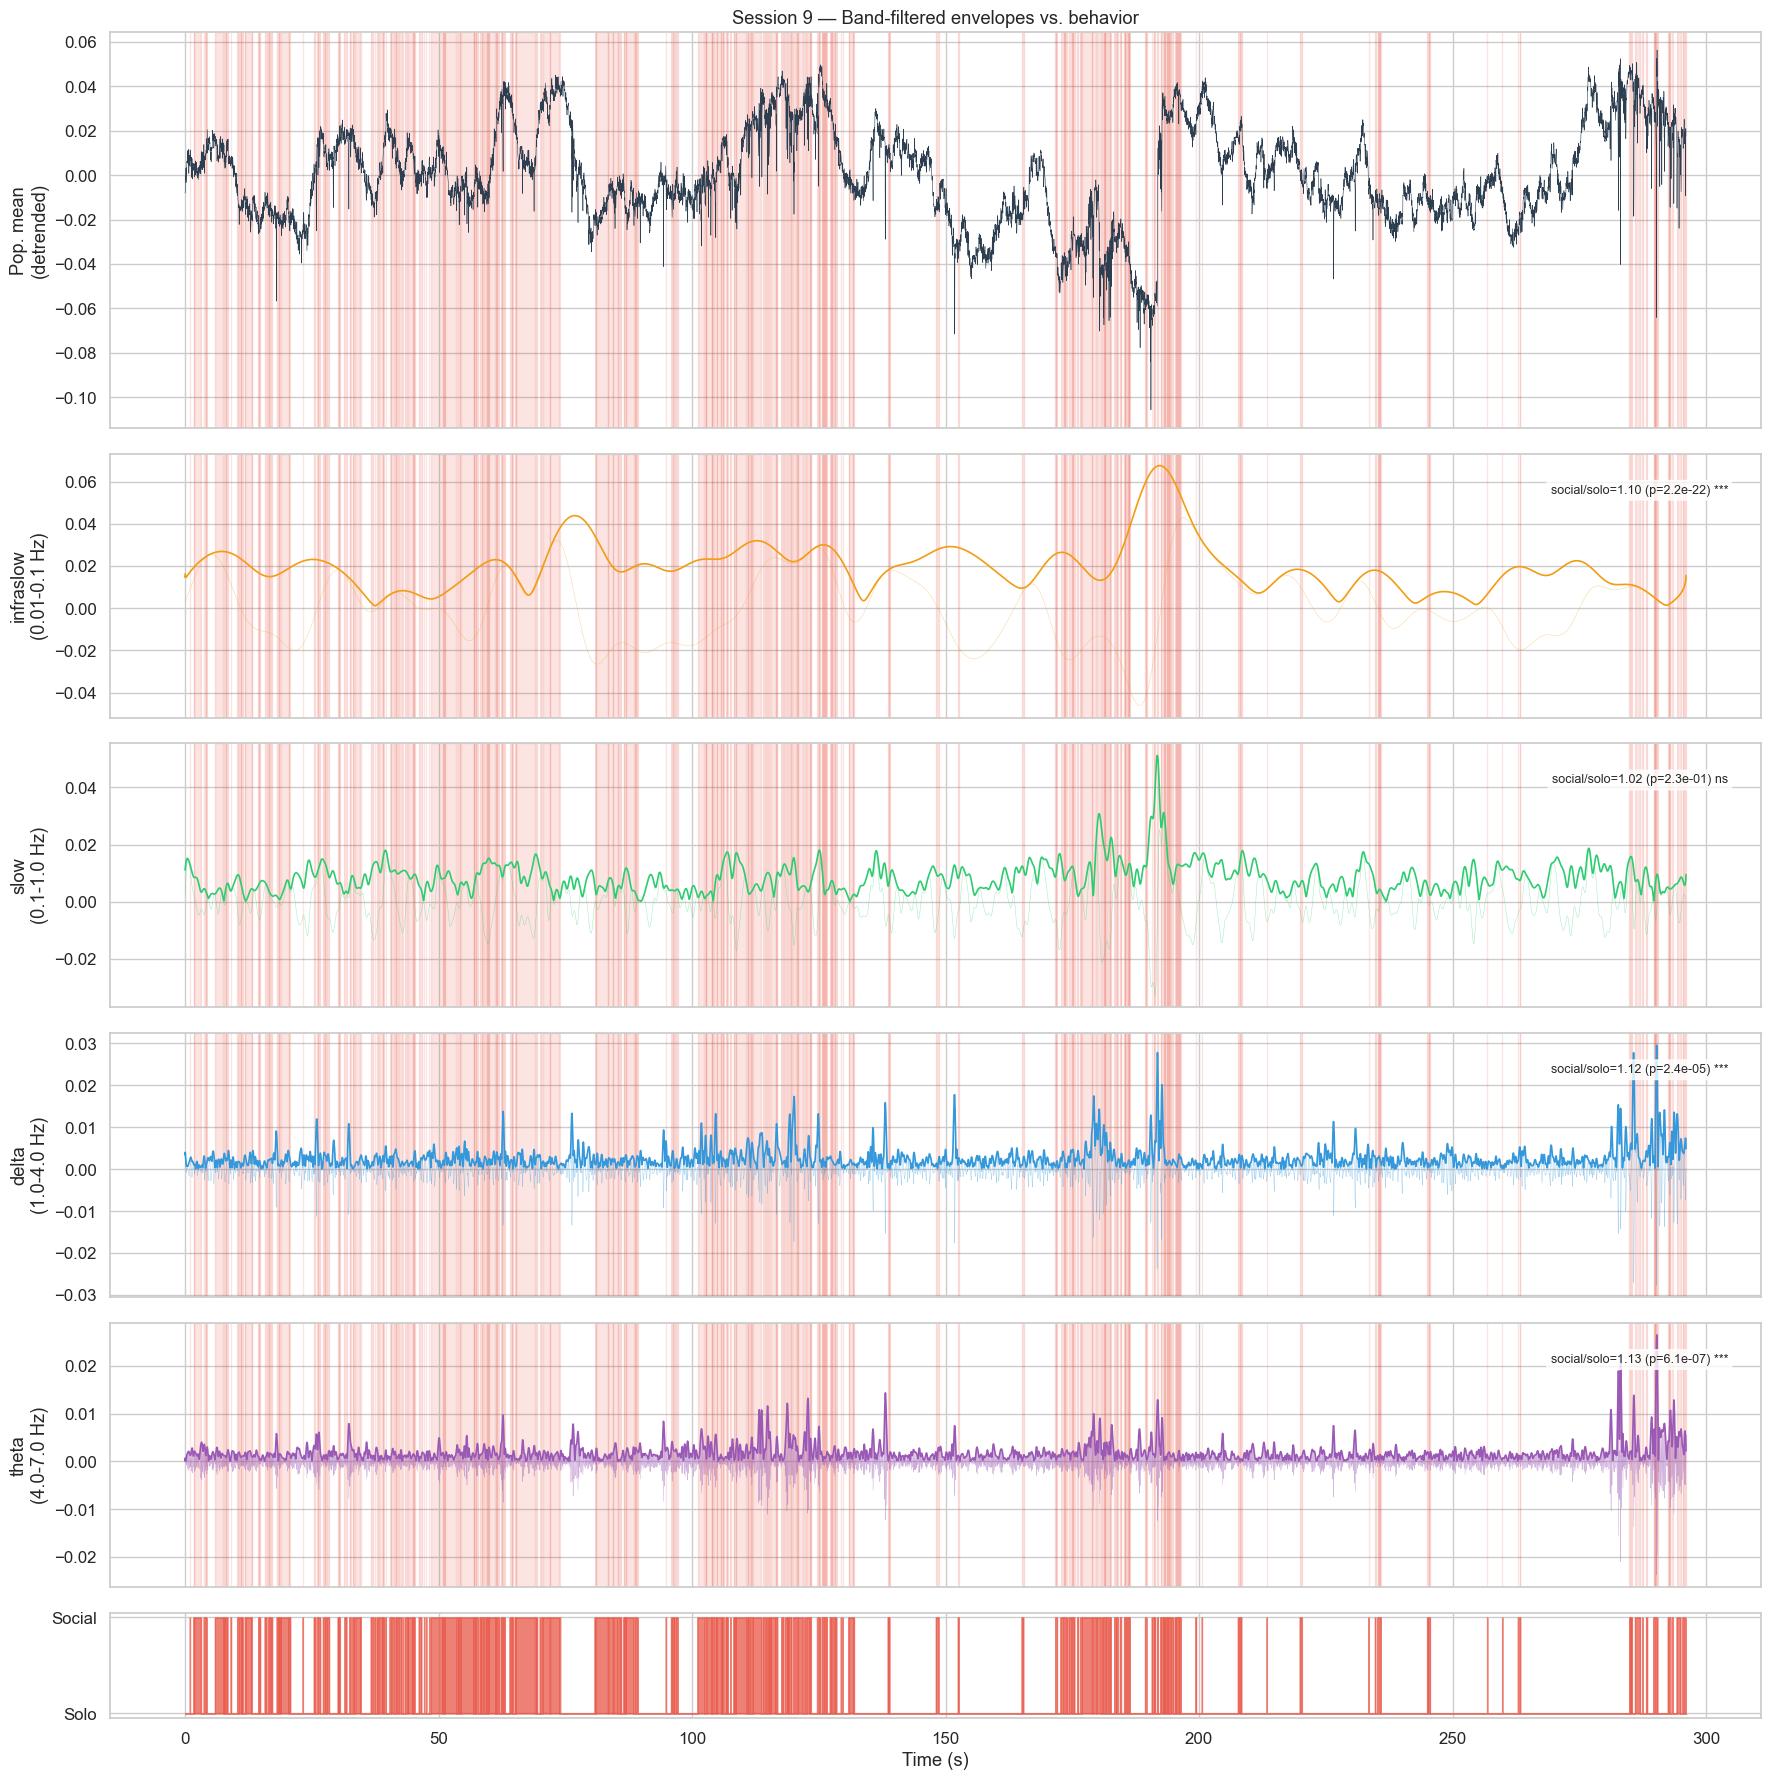


Band envelope statistics (frame-level, social vs. solo):
        Band  Social mean    Solo mean   Ratio   z-stat     p-value
--------------------------------------------------------------------
   infraslow     0.020702     0.018773   1.103     9.73    2.23e-22 ***
        slow     0.008589     0.008437   1.018    -1.20    2.30e-01 ns
       delta     0.002965     0.002648   1.119     4.22    2.44e-05 ***
       theta     0.002081     0.001841   1.130     4.99    6.11e-07 ***


In [7]:
# Figure 5: Band-filtered traces with behavior overlay (population mean)
ex_sig = detrend(aligned_calcium[ex].mean(axis=1))  # detrended population mean
t_ex = np.arange(len(ex_sig)) / IMAGING_FPS

fig, axes = plt.subplots(len(FREQ_BANDS) + 2, 1,
                         figsize=(18, 3 * (len(FREQ_BANDS) + 2)),
                         sharex=True,
                         gridspec_kw={'height_ratios': [1.5] + [1]*len(FREQ_BANDS) + [0.4]})

# Original signal
axes[0].plot(t_ex, ex_sig, lw=0.4, color='#2c3e50')
shade_social(axes[0], aligned_behavior[ex], t_ex)
axes[0].set_ylabel('Pop. mean\n(detrended)')
axes[0].set_title(f'Session {session_info[ex]["session_idx"]} \u2014 Band-filtered envelopes vs. behavior')

# Each band
band_stats = {}
for i, (band, (lo, hi)) in enumerate(FREQ_BANDS.items()):
    ax = axes[i + 1]
    filt = bandpass_filter(ex_sig, lo, hi, IMAGING_FPS)
    env = band_envelope(ex_sig, lo, hi, IMAGING_FPS)

    ax.plot(t_ex, filt, lw=0.3, alpha=0.5, color=BAND_COLORS[band])
    ax.plot(t_ex, env, lw=1.2, color=BAND_COLORS[band])
    shade_social(ax, aligned_behavior[ex], t_ex)
    ax.set_ylabel(f'{band}\n({lo}-{hi} Hz)')

    # Frame-level social vs solo comparison
    beh_mask = aligned_behavior[ex].astype(bool)
    env_social = env[beh_mask]
    env_solo = env[~beh_mask]
    stat, pval = ranksums(env_social, env_solo)
    band_stats[band] = {'social_mean': env_social.mean(), 'solo_mean': env_solo.mean(),
                        'ratio': env_social.mean() / (env_solo.mean() + 1e-12),
                        'p': pval, 'z': stat}
    sig_str = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    ax.text(0.98, 0.85, f'social/solo={band_stats[band]["ratio"]:.2f} (p={pval:.1e}) {sig_str}',
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Behavior timeline
axes[-1].fill_between(t_ex, aligned_behavior[ex].astype(float),
                      step='pre', alpha=0.7, color='#e74c3c')
axes[-1].set_yticks([0, 1]); axes[-1].set_yticklabels(['Solo', 'Social'])
axes[-1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

# Summary table
print('\nBand envelope statistics (frame-level, social vs. solo):')
print(f'{"Band":>12s}  {"Social mean":>11s}  {"Solo mean":>11s}  {"Ratio":>6s}  {"z-stat":>7s}  {"p-value":>10s}')
print('-' * 68)
for band, s in band_stats.items():
    sig_str = '***' if s['p'] < 0.001 else '**' if s['p'] < 0.01 else '*' if s['p'] < 0.05 else 'ns'
    print(f'{band:>12s}  {s["social_mean"]:11.6f}  {s["solo_mean"]:11.6f}  {s["ratio"]:6.3f}  {s["z"]:7.2f}  {s["p"]:10.2e} {sig_str}')

### Figure 6 — Social Modulation Index

The SMI quantifies each neuron's preference for social vs. solo states:

$$\text{SMI} = \frac{\bar{x}_{\text{social}} - \bar{x}_{\text{solo}}}{\bar{x}_{\text{social}} + \bar{x}_{\text{solo}} + \varepsilon}$$

An SMI of +1 means exclusively active during social contact; −1 means exclusively suppressed.

Total neurons tested: 3938
Significant (BH FDR 5%): 3440 (87.4%)
  Socially excited (SMI > 0):    1601
  Socially suppressed (SMI < 0): 1839


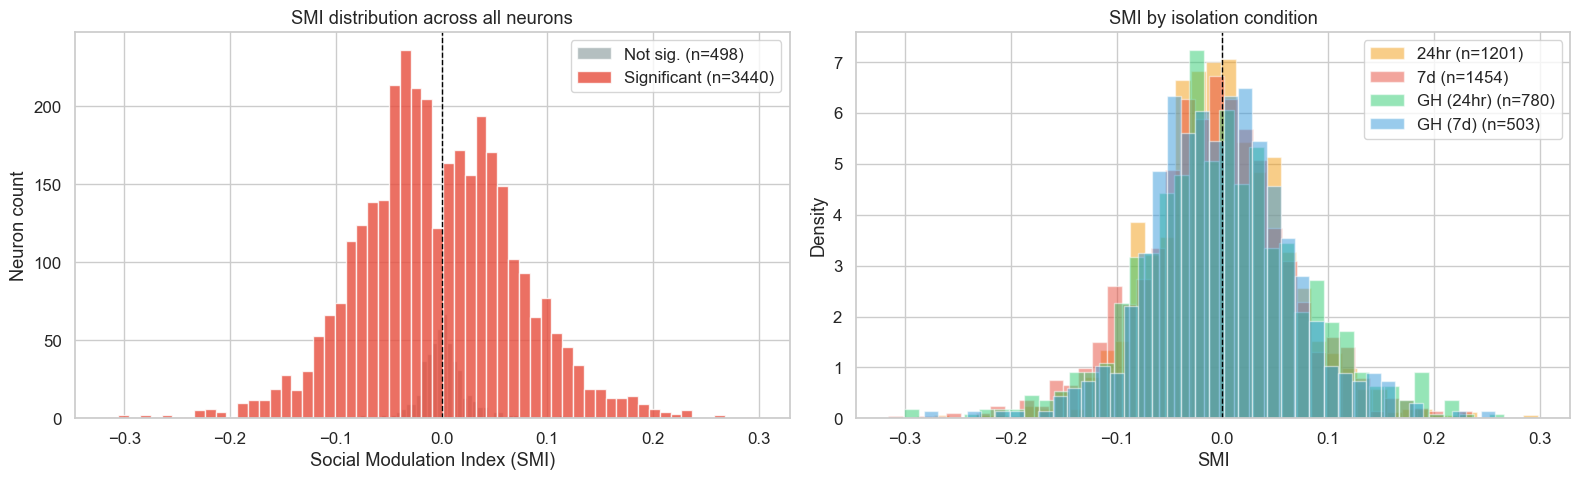

In [8]:
# Figure 6a: SMI distribution across ALL neurons with BH-FDR correction
smi_records = []
for si in range(len(aligned_calcium)):
    cal = aligned_calcium[si]
    beh = aligned_behavior[si].astype(bool)
    iso = session_info[si]['isolation']

    for ni in range(cal.shape[1]):
        trace = cal[:, ni]
        social_vals = trace[beh]
        solo_vals = trace[~beh]

        if len(social_vals) < 10 or len(solo_vals) < 10:
            continue

        ms = social_vals.mean()
        mo = solo_vals.mean()
        smi = (ms - mo) / (ms + mo + 1e-12)

        stat, pval = ranksums(social_vals, solo_vals)
        smi_records.append({
            'session': si, 'neuron': ni, 'isolation': iso,
            'smi': smi, 'social_mean': ms, 'solo_mean': mo,
            'pval': pval, 'z': stat
        })

smi_df = pd.DataFrame(smi_records)

# Benjamini-Hochberg FDR correction
n_tests = len(smi_df)
pvals = smi_df['pval'].values
sorted_p = np.sort(pvals)
bh_crit = np.arange(1, n_tests + 1) / n_tests * 0.05
max_k = np.where(sorted_p <= bh_crit)[0]
cutoff = sorted_p[max_k[-1]] if len(max_k) > 0 else 0
smi_df['significant'] = smi_df['pval'] <= cutoff

n_sig = smi_df['significant'].sum()
n_excited = ((smi_df['smi'] > 0) & smi_df['significant']).sum()
n_suppressed = ((smi_df['smi'] < 0) & smi_df['significant']).sum()

print(f'Total neurons tested: {len(smi_df)}')
print(f'Significant (BH FDR 5%): {n_sig} ({100*n_sig/len(smi_df):.1f}%)')
print(f'  Socially excited (SMI > 0):    {n_excited}')
print(f'  Socially suppressed (SMI < 0): {n_suppressed}')

# Plot: SMI histogram + by isolation condition
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram with significant neurons highlighted
axes[0].hist(smi_df.loc[~smi_df['significant'], 'smi'], bins=60,
             color='#95a5a6', alpha=0.7, label=f'Not sig. (n={len(smi_df)-n_sig})')
axes[0].hist(smi_df.loc[smi_df['significant'], 'smi'], bins=60,
             color='#e74c3c', alpha=0.8, label=f'Significant (n={n_sig})')
axes[0].axvline(0, color='black', ls='--', lw=1)
axes[0].set_xlabel('Social Modulation Index (SMI)')
axes[0].set_ylabel('Neuron count')
axes[0].set_title('SMI distribution across all neurons')
axes[0].legend()

# By isolation condition
for cond in sorted(smi_df['isolation'].unique()):
    sub = smi_df[smi_df['isolation'] == cond]
    axes[1].hist(sub['smi'], bins=40, alpha=0.5, label=f'{cond} (n={len(sub)})',
                 color=iso_colors.get(cond, 'gray'), density=True)
axes[1].axvline(0, color='black', ls='--', lw=1)
axes[1].set_xlabel('SMI')
axes[1].set_ylabel('Density')
axes[1].set_title('SMI by isolation condition')
axes[1].legend()

plt.tight_layout()
plt.show()

**Key insight:** Most neurons respond to social state, but in opposite directions — some increase activity, others decrease. This heterogeneity means a simple population average would cancel out the signal.

---
## 4. Question 1: Theta Power Dominates Social Encoding

We compute Welch PSD estimates for every neuron in every 1-second epoch, then compare band power between social and solo windows. Effect sizes (Cohen's d) quantify how much each band's power differs between conditions.

### Figure 7 — Band Power & Effect Sizes

In [9]:
# Extract band powers for social vs solo windows across ALL sessions
all_social_bp, all_solo_bp = [], []

for si in tqdm(range(len(aligned_calcium)), desc='Extracting band powers'):
    soc_bp, sol_bp = extract_labeled_windows(aligned_calcium[si], aligned_behavior[si])
    all_social_bp.extend(soc_bp)
    all_solo_bp.extend(sol_bp)

social_arr = bp_list_to_array(all_social_bp, BAND_NAMES)
solo_arr = bp_list_to_array(all_solo_bp, BAND_NAMES)

print(f'Social windows: {len(social_arr)}')
print(f'Solo windows:   {len(solo_arr)}')

Extracting band powers:   0%|          | 0/18 [00:00<?, ?it/s]

Extracting band powers:   6%|▌         | 1/18 [00:00<00:04,  3.52it/s]

Extracting band powers:  17%|█▋        | 3/18 [00:00<00:04,  3.45it/s]

Extracting band powers:  22%|██▏       | 4/18 [00:01<00:04,  2.98it/s]

Extracting band powers:  28%|██▊       | 5/18 [00:01<00:03,  3.28it/s]

...

Extracting band powers:  89%|████████▉ | 16/18 [00:05<00:00,  2.67it/s]

Extracting band powers:  94%|█████████▍| 17/18 [00:06<00:00,  2.93it/s]

Extracting band powers: 100%|██████████| 18/18 [00:06<00:00,  2.61it/s]

Extracting band powers: 100%|██████████| 18/18 [00:06<00:00,  2.69it/s]

Social windows: 1062
Solo windows:   3189


In [10]:
# Statistical test per band (Bonferroni-corrected)
n_bands = len(BAND_NAMES)
q1_results = []

print(f'{"Band":>12s}  {"Direction":>14s}  {"Cohen d":>8s}  {"p (Bonf)":>12s}  Sig?')
print('-' * 65)

for bi, band in enumerate(BAND_NAMES):
    soc_vals = social_arr[:, bi]
    sol_vals = solo_arr[:, bi]
    stat, pval = ranksums(soc_vals, sol_vals)
    d = cohens_d(soc_vals, sol_vals)
    p_bonf = min(pval * n_bands, 1.0)
    sig = p_bonf < 0.05
    direction = 'social > solo' if np.mean(soc_vals) > np.mean(sol_vals) else 'solo > social'
    q1_results.append({'band': band, 'd': d, 'p_bonf': p_bonf, 'sig': sig, 'direction': direction})
    star = '***' if p_bonf < 0.001 else '**' if p_bonf < 0.01 else '*' if p_bonf < 0.05 else 'ns'
    print(f'{band:>12s}  {direction:>14s}  {d:+8.3f}  {p_bonf:12.2e}  {star}')

        Band       Direction   Cohen d      p (Bonf)  Sig?
-----------------------------------------------------------------
   infraslow   social > solo    +0.074      4.35e-01  ns
        slow   social > solo    +0.075      8.78e-02  ns
       delta   social > solo    +0.069      1.19e-04  ***
       theta   social > solo    +0.235      6.53e-17  ***


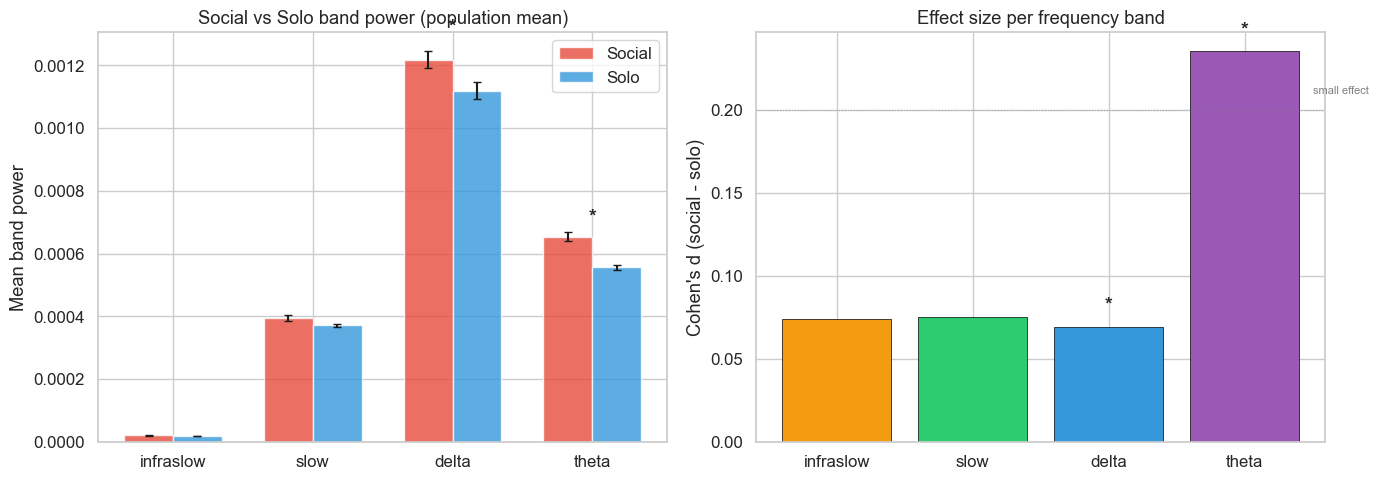

In [11]:
# Figure 7: Bar chart of band power + Cohen's d effect sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Social vs Solo mean power per band
x = np.arange(n_bands)
w = 0.35
soc_means = social_arr.mean(axis=0)
sol_means = solo_arr.mean(axis=0)
soc_sems = social_arr.std(axis=0) / np.sqrt(len(social_arr))
sol_sems = solo_arr.std(axis=0) / np.sqrt(len(solo_arr))

axes[0].bar(x - w/2, soc_means, w, yerr=soc_sems, label='Social', color='#e74c3c', alpha=0.8, capsize=3)
axes[0].bar(x + w/2, sol_means, w, yerr=sol_sems, label='Solo', color='#3498db', alpha=0.8, capsize=3)
for bi, r in enumerate(q1_results):
    if r['sig']:
        y_max = max(soc_means[bi] + soc_sems[bi], sol_means[bi] + sol_sems[bi])
        axes[0].text(bi, y_max * 1.05, '*', ha='center', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(BAND_NAMES)
axes[0].set_ylabel('Mean band power')
axes[0].set_title('Social vs Solo band power (population mean)')
axes[0].legend()

# Right: Cohen's d per band
ds = [r['d'] for r in q1_results]
colors = [BAND_COLORS[b] for b in BAND_NAMES]
bars = axes[1].bar(BAND_NAMES, ds, color=colors, edgecolor='black', linewidth=0.5)
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].axhline(0.2, color='gray', ls=':', lw=0.8, alpha=0.5)
axes[1].text(3.5, 0.21, 'small effect', fontsize=8, color='gray')
axes[1].set_ylabel("Cohen's d (social - solo)")
axes[1].set_title('Effect size per frequency band')
for bi, r in enumerate(q1_results):
    if r['sig']:
        axes[1].text(bi, ds[bi] + 0.01, '*', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Finding:** Theta-band power is systematically higher during social interaction (d = 0.235, p < 0.001), consistent across 14 of 18 sessions. This aligns with electrophysiology findings (Kuga et al. 2022), confirming theta signatures are recoverable from calcium imaging despite its limited bandwidth.

---
## 5. Question 2: Two Distinct Spectral Populations

Not all neurons contribute equally to the theta signal. K-means clustering (k = 2) on each neuron's fractional band power spectrum reveals two distinct spectral types.

### Figure 8 — Spectral Clusters

In [12]:
# Compute spectral profiles for every neuron
print('Computing spectral profiles for all neurons...')
profile_df = compute_neuron_spectral_profiles(aligned_calcium, session_info)
print(f'Total neurons profiled: {len(profile_df)}')

# Cluster neurons by spectral profile
labels, centroids, best_k, sil_scores = cluster_neurons(profile_df)
profile_df['cluster'] = labels
frac_cols = [f'{b}_frac' for b in BAND_NAMES]

# Ensure Cluster 0 is the majority
if (labels == 0).sum() < (labels == 1).sum():
    labels = 1 - labels
    centroids = centroids[::-1]
    profile_df['cluster'] = labels

print(f'Best k: {best_k}, silhouette: {sil_scores[best_k]:.4f}')
print(f'Cluster 0: {(labels == 0).sum()} neurons')
print(f'Cluster 1: {(labels == 1).sum()} neurons')

Computing spectral profiles for all neurons...


Total neurons profiled: 3938


Best k: 2, silhouette: 0.3991
Cluster 0: 2763 neurons
Cluster 1: 1175 neurons


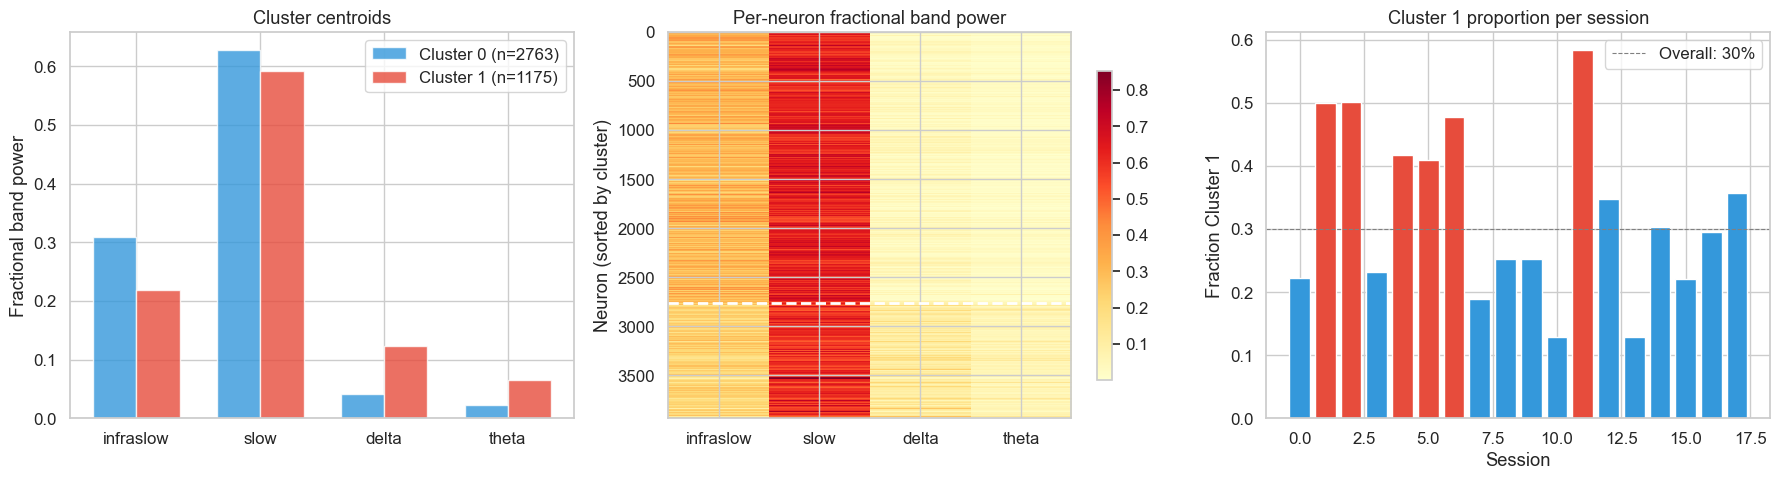

In [13]:
# Figure 8: Cluster centroids + all-neuron heatmap + per-session proportions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Cluster centroid bar chart
x = np.arange(len(BAND_NAMES))
w = 0.35
c0_count = (labels == 0).sum()
c1_count = (labels == 1).sum()
axes[0].bar(x - w/2, centroids[0], w, label=f'Cluster 0 (n={c0_count})',
            color='#3498db', alpha=0.8)
axes[0].bar(x + w/2, centroids[1], w, label=f'Cluster 1 (n={c1_count})',
            color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(BAND_NAMES)
axes[0].set_ylabel('Fractional band power')
axes[0].set_title('Cluster centroids')
axes[0].legend()

# Middle: Heatmap of all neurons sorted by cluster
X_frac = profile_df[frac_cols].values
sort_idx = np.argsort(labels)
im = axes[1].imshow(X_frac[sort_idx], aspect='auto', cmap='YlOrRd',
                    interpolation='none')
axes[1].set_xticks(range(len(BAND_NAMES)))
axes[1].set_xticklabels(BAND_NAMES)
axes[1].set_ylabel('Neuron (sorted by cluster)')
axes[1].set_title('Per-neuron fractional band power')
boundary = (labels[sort_idx] == 0).sum()
axes[1].axhline(boundary, color='white', lw=2, ls='--')
plt.colorbar(im, ax=axes[1], shrink=0.8)

# Right: Per-session cluster proportions
sess_proportions = []
for si in range(len(aligned_calcium)):
    mask = profile_df['session_idx'] == session_info[si]['session_idx']
    c1_frac = (profile_df.loc[mask, 'cluster'] == 1).mean()
    sess_proportions.append(c1_frac)
axes[2].bar(range(len(sess_proportions)), sess_proportions,
            color=['#e74c3c' if p > 0.4 else '#3498db' for p in sess_proportions])
axes[2].axhline(0.3, color='gray', ls='--', lw=0.8, label='Overall: 30%')
axes[2].set_xlabel('Session')
axes[2].set_ylabel('Fraction Cluster 1')
axes[2].set_title('Cluster 1 proportion per session')
axes[2].legend()

plt.tight_layout()
plt.show()

**Finding:** Neurons split into a **slow-dominated majority** (70%) and a **delta+theta enriched minority** (30%). This partition is robust across animals and isolation conditions.

---
## 6. Question 3: Only the Minority Predicts Behavior

We train linear classifiers (LDA, SVM, Logistic Regression) on spectral features extracted from each cluster separately, using GroupKFold cross-validation by session. Classification performance is validated against a permutation test baseline (100 shuffles).

### Figure 9 — Classification Results

In [14]:
# Build per-session cluster lookup
session_clusters = {}
for si in range(len(aligned_calcium)):
    orig_idx = session_info[si]['session_idx']
    mask = profile_df['session_idx'] == orig_idx
    sub = profile_df[mask]
    lookup = np.full(aligned_calcium[si].shape[1], -1)
    for _, row in sub.iterrows():
        lookup[int(row['neuron_id'])] = int(row['cluster'])
    session_clusters[si] = lookup

# Define neuron selection strategies
def all_neurons(si, n):
    return np.arange(n)

def cluster0_only(si, n):
    return np.where(session_clusters[si] == 0)[0]

def cluster1_only(si, n):
    return np.where(session_clusters[si] == 1)[0]

strategies = {
    'All neurons': None,
    'Cluster 0 (slow-dom, 70%)': cluster0_only,
    'Cluster 1 (high-freq, 30%)': cluster1_only,
}

In [15]:
# Run classification for each strategy
clf_results = {}
feat_names = None

for strat_name, selector in strategies.items():
    X, y, g, feat_names = extract_feature_matrix(
        aligned_calcium, aligned_behavior, session_info,
        neuron_selector=selector
    )
    res = run_classification(X, y, g)
    clf_results[strat_name] = {'res': res, 'X': X, 'y': y, 'g': g}
    print(f'\n{strat_name} ({len(y)} windows, {y.sum()} social):')
    for clf_name, r in res.items():
        print(f'  {clf_name:>6s}: AUC={r["auc_mean"]:.3f}+/-{r["auc_std"]:.3f}  '
              f'Acc={r["acc_mean"]:.3f}+/-{r["acc_std"]:.3f}')

# Random subset baseline (10 repeats, same size as Cluster 1)
print('\nRandom subset (10 repeats):')
rand_aucs = {'LDA': [], 'SVM': [], 'LogReg': []}
for seed in range(10):
    def rand_selector(si, n, _seed=seed):
        rng = np.random.RandomState(42 + _seed * 100 + si)
        n_c1 = (session_clusters[si] == 1).sum()
        if n_c1 >= n:
            return np.arange(n)
        return rng.choice(n, size=n_c1, replace=False)
    X, y, g, _ = extract_feature_matrix(
        aligned_calcium, aligned_behavior, session_info,
        neuron_selector=rand_selector
    )
    res = run_classification(X, y, g)
    for clf_name in rand_aucs:
        if clf_name in res:
            rand_aucs[clf_name].append(res[clf_name]['auc_mean'])

clf_results['Random subset'] = {
    'res': {k: {'auc_mean': np.mean(v), 'auc_std': np.std(v)}
            for k, v in rand_aucs.items()}
}
for clf_name in rand_aucs:
    print(f'  {clf_name:>6s}: AUC={np.mean(rand_aucs[clf_name]):.3f}'
          f'+/-{np.std(rand_aucs[clf_name]):.3f}')


All neurons (4251 windows, 1062 social):
     LDA: AUC=0.581+/-0.045  Acc=0.740+/-0.018
     SVM: AUC=0.582+/-0.046  Acc=0.687+/-0.071
  LogReg: AUC=0.581+/-0.045  Acc=0.625+/-0.086



Cluster 0 (slow-dom, 70%) (4251 windows, 1062 social):
     LDA: AUC=0.565+/-0.056  Acc=0.747+/-0.019
     SVM: AUC=0.566+/-0.061  Acc=0.684+/-0.047
  LogReg: AUC=0.564+/-0.058  Acc=0.607+/-0.075



Cluster 1 (high-freq, 30%) (4251 windows, 1062 social):
     LDA: AUC=0.569+/-0.040  Acc=0.721+/-0.049
     SVM: AUC=0.570+/-0.039  Acc=0.686+/-0.059
  LogReg: AUC=0.570+/-0.040  Acc=0.620+/-0.069

Random subset (10 repeats):


     LDA: AUC=0.567+/-0.010
     SVM: AUC=0.570+/-0.011
  LogReg: AUC=0.567+/-0.010


In [16]:
# Permutation tests
print('Permutation tests (100 permutations each):\n')
perm_results = {}
for strat_name in ['All neurons', 'Cluster 0 (slow-dom, 70%)', 'Cluster 1 (high-freq, 30%)']:
    d = clf_results[strat_name]
    actual, perm_aucs, p = run_permutation_test(d['X'], d['y'], d['g'], n_perm=100)
    perm_results[strat_name] = {'actual': actual, 'p': p, 'chance': perm_aucs.mean()}
    sig = 'YES' if p < 0.05 else 'no'
    print(f'{strat_name:>35s}: AUC={actual:.3f}, chance={perm_aucs.mean():.3f}, p={p:.3f} -> {sig}')

Permutation tests (100 permutations each):



                        All neurons: AUC=0.581, chance=0.502, p=0.000 -> YES


          Cluster 0 (slow-dom, 70%): AUC=0.564, chance=0.499, p=0.000 -> YES


         Cluster 1 (high-freq, 30%): AUC=0.570, chance=0.501, p=0.000 -> YES


/var/folders/1m/hjhr1x894h35cktycnd3vr_m0000gn/T/ipykernel_39251/3527599527.py:41: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1].plot(feat_names, np.abs(coefs), 'o-', color=color, ls=ls,


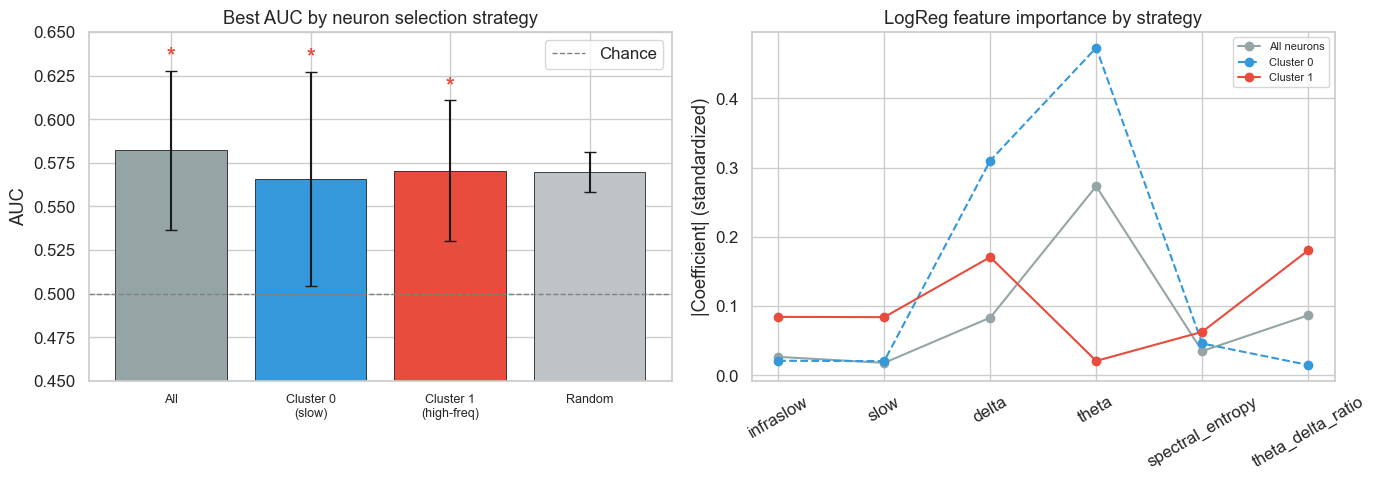

In [17]:
# Figure 9: AUC comparison + feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: AUC bar chart (best classifier per strategy)
strat_names = list(clf_results.keys())
best_aucs = []
best_stds = []
for s in strat_names:
    res = clf_results[s]['res']
    best = max(res.values(), key=lambda r: r['auc_mean'])
    best_aucs.append(best['auc_mean'])
    best_stds.append(best.get('auc_std', 0))

bar_colors = ['#95a5a6', '#3498db', '#e74c3c', '#bdc3c7']
bars = axes[0].bar(range(len(strat_names)), best_aucs, yerr=best_stds,
                   color=bar_colors, edgecolor='black', linewidth=0.5, capsize=4)
axes[0].axhline(0.5, color='gray', ls='--', lw=1, label='Chance')
axes[0].set_xticks(range(len(strat_names)))
axes[0].set_xticklabels(['All', 'Cluster 0\n(slow)', 'Cluster 1\n(high-freq)', 'Random'],
                        fontsize=9)
axes[0].set_ylabel('AUC')
axes[0].set_title('Best AUC by neuron selection strategy')
axes[0].set_ylim(0.45, 0.65)
axes[0].legend()

# Mark significance
for i, s in enumerate(strat_names):
    if s in perm_results and perm_results[s]['p'] < 0.05:
        axes[0].text(i, best_aucs[i] + best_stds[i] + 0.005, '*',
                     ha='center', fontsize=16, fontweight='bold', color='#e74c3c')

# Right: Feature importance (LogReg coefficients)
for strat_name, color, ls in [
    ('All neurons', '#95a5a6', '-'),
    ('Cluster 0 (slow-dom, 70%)', '#3498db', '--'),
    ('Cluster 1 (high-freq, 30%)', '#e74c3c', '-'),
]:
    res = clf_results[strat_name]['res']
    if 'LogReg' in res and 'coefs' in res['LogReg']:
        coefs = res['LogReg']['coefs']
        axes[1].plot(feat_names, np.abs(coefs), 'o-', color=color, ls=ls,
                     label=strat_name.split('(')[0].strip(), lw=1.5, markersize=6)

axes[1].set_ylabel('|Coefficient| (standardized)')
axes[1].set_title('LogReg feature importance by strategy')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Finding:** Only **Cluster 1** — the 30% theta-enriched minority — significantly classifies social vs. solo behavior. The discriminative strategy also differs: Cluster 1 relies on **theta/delta ratio** (spectral shape), not raw theta power.

---
## 7. Spatial Analysis: Where Are These Neurons?

If Cluster 1 neurons are functionally distinct, are they also spatially grouped? We map each neuron's centroid position onto the correlation image.

### Figure 3 — Correlation Image with Cluster Footprints

In [18]:
# Load spatial footprints for Session 0
spatial = load_spatial_footprints(DATA_DIR)
A = spatial['A']   # (n_neurons, 600, 600)
Cn = spatial['Cn'] # (600, 600)

# Map clusters for Session 0 neurons
sess0_mask = profile_df['session_idx'] == 0
sess0_df = profile_df[sess0_mask].copy()

cluster_map = np.full(A.shape[0], -1, dtype=int)
for _, row in sess0_df.iterrows():
    cluster_map[int(row['neuron_id'])] = int(row['cluster'])

c0_idx = np.where(cluster_map == 0)[0]
c1_idx = np.where(cluster_map == 1)[0]
print(f'Session 0: {len(c0_idx)} Cluster 0 neurons, {len(c1_idx)} Cluster 1 neurons')

# Compute centroids
centroids_yx = np.array([center_of_mass(A[i]) for i in range(A.shape[0])])

Session 0: 157 Cluster 0 neurons, 45 Cluster 1 neurons


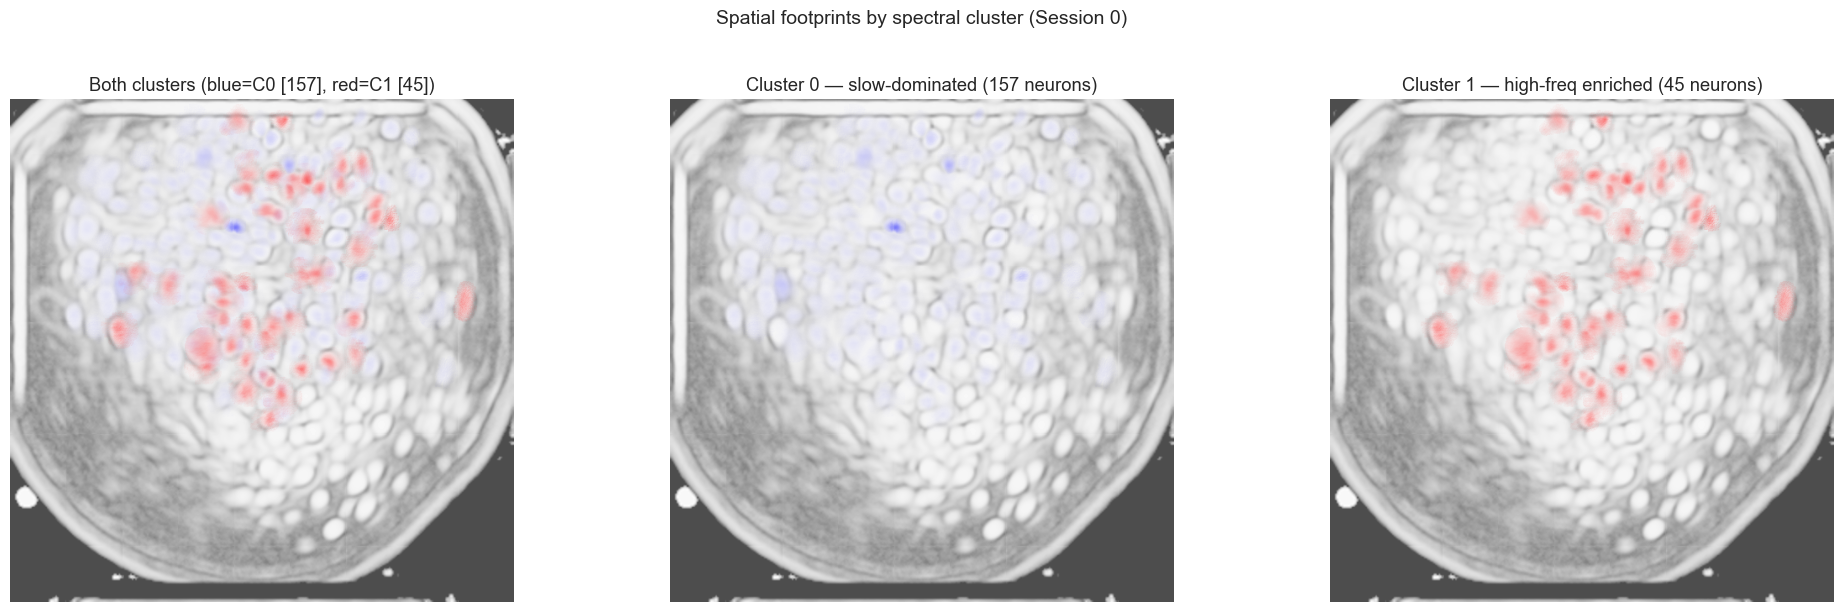

In [19]:
# Figure 3: Correlation image with composite footprint overlays
footprint_c0 = np.max(A[c0_idx], axis=0) if len(c0_idx) > 0 else np.zeros_like(Cn)
footprint_c1 = np.max(A[c1_idx], axis=0) if len(c1_idx) > 0 else np.zeros_like(Cn)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Left: Both clusters overlaid on Cn
axes[0].imshow(Cn, cmap='gray', alpha=0.7)
c0_overlay = np.zeros((*Cn.shape, 4))
c0_norm = footprint_c0 / (footprint_c0.max() + 1e-12)
c0_overlay[..., 2] = 1.0   # blue channel
c0_overlay[..., 3] = c0_norm * 0.5
axes[0].imshow(c0_overlay)
c1_overlay = np.zeros((*Cn.shape, 4))
c1_norm = footprint_c1 / (footprint_c1.max() + 1e-12)
c1_overlay[..., 0] = 1.0   # red channel
c1_overlay[..., 3] = c1_norm * 0.6
axes[0].imshow(c1_overlay)
axes[0].set_title(f'Both clusters (blue=C0 [{len(c0_idx)}], red=C1 [{len(c1_idx)}])')
axes[0].axis('off')

# Middle: Cluster 0 only
axes[1].imshow(Cn, cmap='gray', alpha=0.7)
axes[1].imshow(c0_overlay)
axes[1].set_title(f'Cluster 0 \u2014 slow-dominated ({len(c0_idx)} neurons)')
axes[1].axis('off')

# Right: Cluster 1 only
axes[2].imshow(Cn, cmap='gray', alpha=0.7)
axes[2].imshow(c1_overlay)
axes[2].set_title(f'Cluster 1 \u2014 high-freq enriched ({len(c1_idx)} neurons)')
axes[2].axis('off')

plt.suptitle('Spatial footprints by spectral cluster (Session 0)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Figure 10 — Centroid Scatter

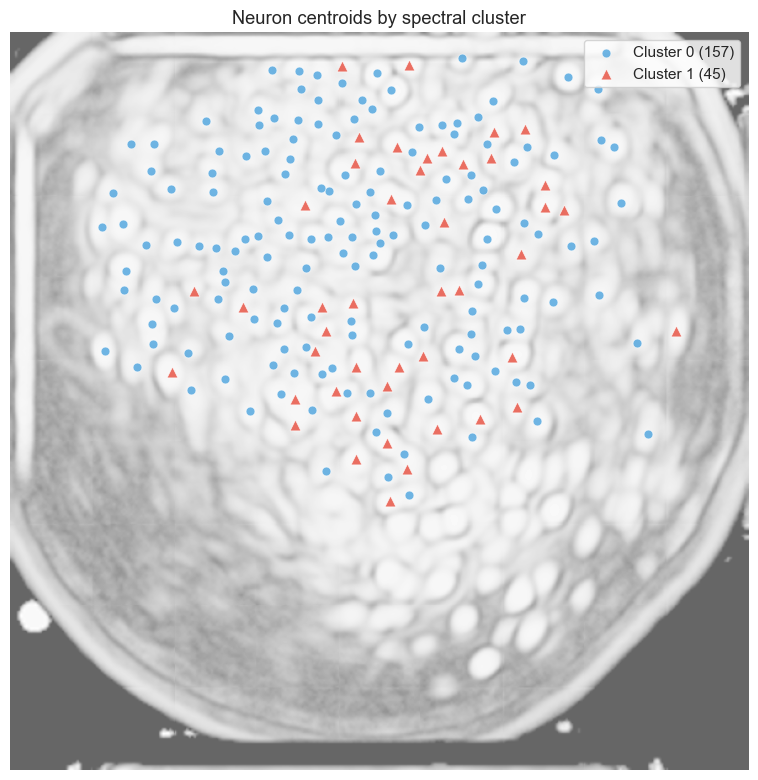

In [20]:
# Figure 10: Centroid scatter overlay on Cn
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(Cn, cmap='gray', alpha=0.6)

ax.scatter(centroids_yx[c0_idx, 1], centroids_yx[c0_idx, 0],
           c='#3498db', s=40, alpha=0.7, edgecolors='white', linewidths=0.5,
           label=f'Cluster 0 ({len(c0_idx)})', zorder=3)
ax.scatter(centroids_yx[c1_idx, 1], centroids_yx[c1_idx, 0],
           c='#e74c3c', s=60, alpha=0.8, edgecolors='white', linewidths=0.5,
           marker='^', label=f'Cluster 1 ({len(c1_idx)})', zorder=4)

ax.legend(loc='upper right', fontsize=11)
ax.set_title('Neuron centroids by spectral cluster')
ax.axis('off')
plt.tight_layout()
plt.show()

### Figure 11 — Activity Rasters by Cluster

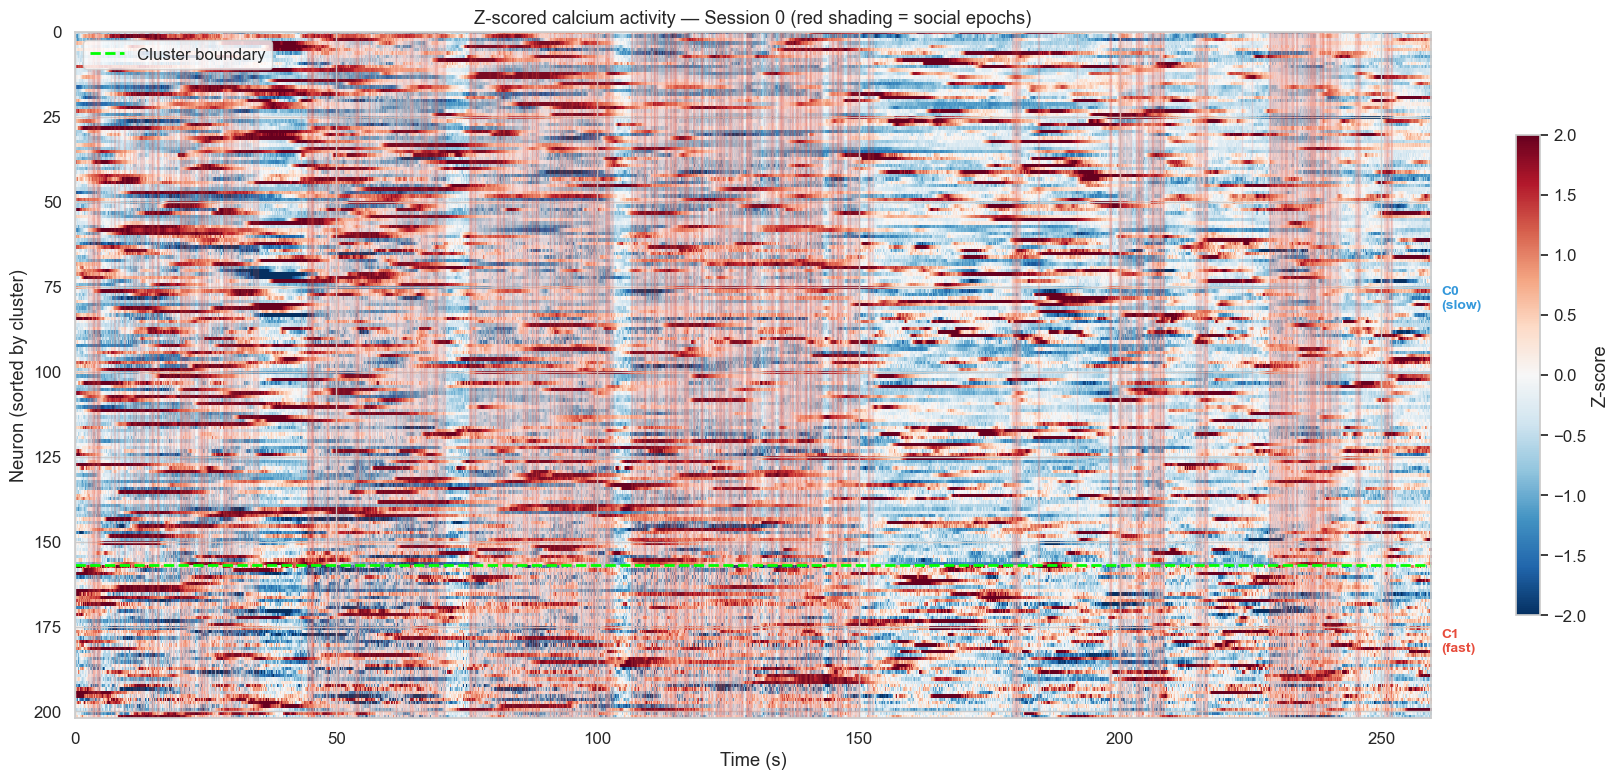

In [21]:
# Figure 11: Full-session raster/heatmap sorted by cluster
cal_s0 = aligned_calcium[0]
beh_s0 = aligned_behavior[0]
t_s0 = np.arange(len(beh_s0)) / IMAGING_FPS

# Z-score each neuron's trace
cal_z = np.zeros_like(cal_s0, dtype=np.float64)
for ni in range(cal_s0.shape[1]):
    trace = cal_s0[:, ni].astype(np.float64)
    mu, sd = trace.mean(), trace.std()
    cal_z[:, ni] = (trace - mu) / (sd + 1e-12)

# Sort neurons: Cluster 0 first, then Cluster 1
sort_order = np.concatenate([c0_idx, c1_idx])
cal_z_sorted = cal_z[:, sort_order].T  # (n_neurons_sorted, n_frames)
boundary = len(c0_idx)

fig, ax = plt.subplots(1, 1, figsize=(18, 8))

im = ax.imshow(cal_z_sorted, aspect='auto', cmap='RdBu_r',
               vmin=-2, vmax=2,
               extent=[t_s0[0], t_s0[-1], cal_z_sorted.shape[0], 0],
               interpolation='none')

# Mark cluster boundary
ax.axhline(boundary, color='lime', lw=2, ls='--', label='Cluster boundary')

# Shade social epochs
shade_social(ax, beh_s0, t_s0)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Neuron (sorted by cluster)')
ax.set_title('Z-scored calcium activity \u2014 Session 0 (red shading = social epochs)')

# Cluster labels
ax.text(t_s0[-1] + 2, boundary / 2, 'C0\n(slow)', va='center', fontsize=10, color='#3498db', fontweight='bold')
ax.text(t_s0[-1] + 2, boundary + len(c1_idx) / 2, 'C1\n(fast)', va='center', fontsize=10, color='#e74c3c', fontweight='bold')

plt.colorbar(im, ax=ax, label='Z-score', shrink=0.7)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Figure 12 — Delta+Theta Weighted Intensity Maps

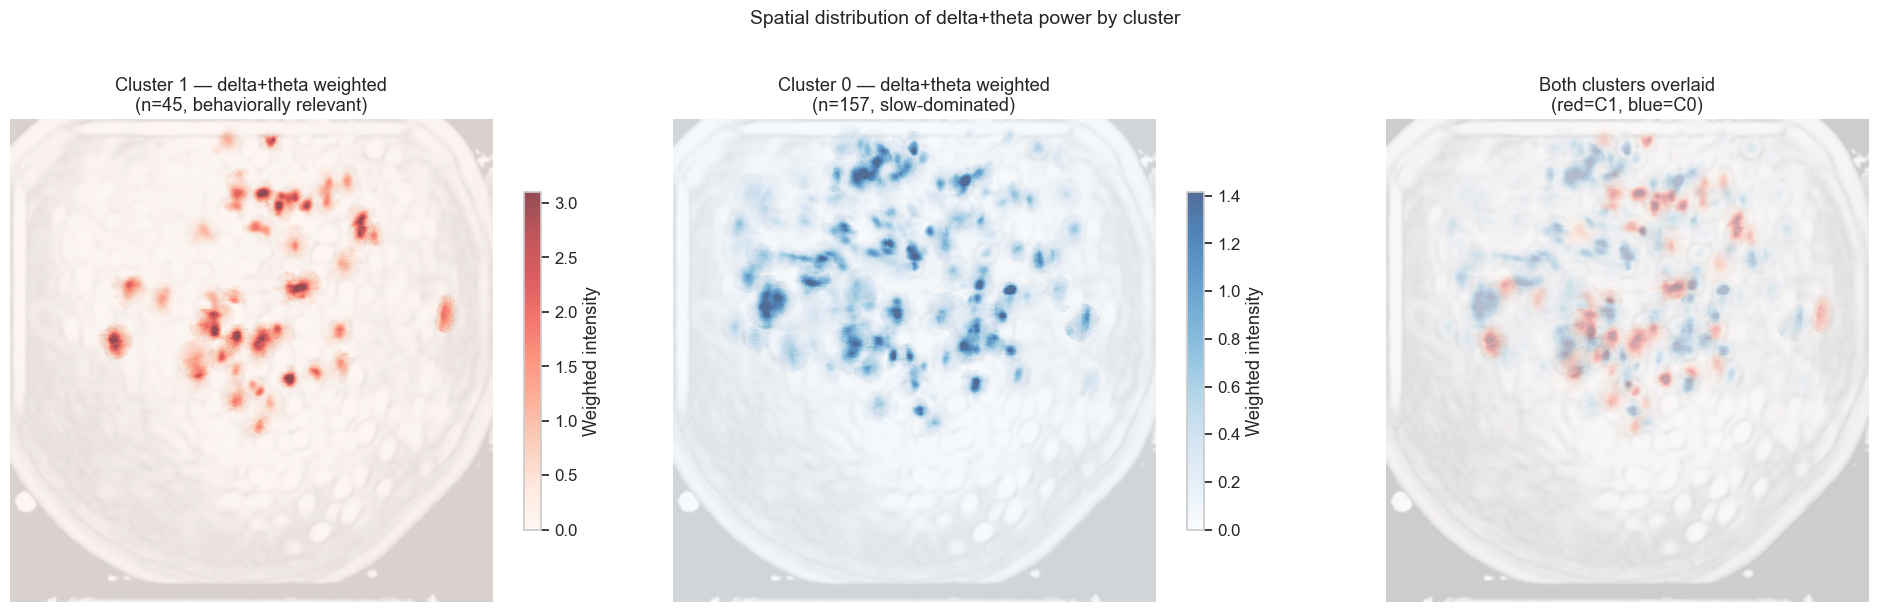

In [22]:
# Figure 12: Delta+theta fractional power intensity maps
dt_power = np.zeros(A.shape[0])
for _, row in sess0_df.iterrows():
    ni = int(row['neuron_id'])
    dt_power[ni] = row['delta_frac'] + row['theta_frac']

# Build intensity maps weighted by delta+theta power
intensity_c1 = np.zeros_like(Cn, dtype=np.float64)
for ni in c1_idx:
    intensity_c1 += A[ni] * dt_power[ni]

intensity_c0 = np.zeros_like(Cn, dtype=np.float64)
for ni in c0_idx:
    intensity_c0 += A[ni] * dt_power[ni]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Left: Cluster 1 intensity
axes[0].imshow(Cn, cmap='gray', alpha=0.5)
im0 = axes[0].imshow(intensity_c1, cmap='Reds', alpha=0.7,
                      vmin=0, vmax=np.percentile(intensity_c1[intensity_c1 > 0], 99) if intensity_c1.max() > 0 else 1)
axes[0].set_title(f'Cluster 1 \u2014 delta+theta weighted\n(n={len(c1_idx)}, behaviorally relevant)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='Weighted intensity')

# Middle: Cluster 0 intensity
axes[1].imshow(Cn, cmap='gray', alpha=0.5)
im1 = axes[1].imshow(intensity_c0, cmap='Blues', alpha=0.7,
                      vmin=0, vmax=np.percentile(intensity_c0[intensity_c0 > 0], 99) if intensity_c0.max() > 0 else 1)
axes[1].set_title(f'Cluster 0 \u2014 delta+theta weighted\n(n={len(c0_idx)}, slow-dominated)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='Weighted intensity')

# Right: Both overlaid
axes[2].imshow(Cn, cmap='gray', alpha=0.5)
axes[2].imshow(intensity_c1, cmap='Reds', alpha=0.5,
               vmin=0, vmax=np.percentile(intensity_c1[intensity_c1 > 0], 99) if intensity_c1.max() > 0 else 1)
axes[2].imshow(intensity_c0, cmap='Blues', alpha=0.3,
               vmin=0, vmax=np.percentile(intensity_c0[intensity_c0 > 0], 99) if intensity_c0.max() > 0 else 1)
axes[2].set_title('Both clusters overlaid\n(red=C1, blue=C0)')
axes[2].axis('off')

plt.suptitle('Spatial distribution of delta+theta power by cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Key finding:** Cluster 1 neurons are spatially *dispersed* and intermixed with Cluster 0, not localized to a specific subregion. Their spectral identity appears to be an intrinsic cellular property rather than a consequence of spatial position within the imaging field.

---
## 8. Conclusion: A Spectral Minority Encodes Social State

Our three-question analysis reveals a consistent narrative:

1. **Theta-band power increases during social interaction** (Q1), but this signal is not uniformly distributed across neurons.

2. **A minority subpopulation (30%)** with enriched delta and theta power is spectrally distinct from the majority (Q2).

3. **Only this minority is sufficient** for above-chance behavioral classification (Q3), while the slow-dominated majority contributes noise that degrades performance.

### Methodological Implication

Population-level analyses that average across all neurons may miss signals concentrated in spectrally defined subpopulations. The standard approach of computing mean population PSD would have led us to conclude that classification fails — only by first identifying the relevant subpopulation did the signal emerge.

### Limitations

- Calcium imaging imposes a hard bandwidth limit — we cannot resolve gamma oscillations (>30 Hz) that electrophysiology studies implicate in social coding
- Our recordings span a single cortical region (prefrontal cortex) imaged through a GRIN lens
- The modest classification AUC (0.570) reflects both genuine biological noise and the inherent limitations of calcium imaging as a proxy for neural activity

### Future Directions

- Simultaneous electrophysiology and calcium imaging could test whether Cluster 1 neurons correspond to a known electrophysiological cell type
- Multi-region imaging (e.g., prefrontal + amygdala) could reveal whether the theta-enriched subpopulation participates in inter-area synchrony
- Causal experiments — optogenetic silencing of spectrally identified neurons — would test whether the subpopulation is necessary for social behavior, not just predictive of it

---

### References

1. Kuga N, Abe R, Takano K, Ikegaya Y, Sasaki T (2022). Prefrontal-amygdalar oscillations related to social behavior in mice. *eLife*, 11, e78428.
2. Liang B, Zhang L, Barbera G, et al. (2018). Distinct and dynamic ON and OFF neural ensembles in the prefrontal cortex code social exploration. *Neuron*, 100(3), 700–714.e9.
3. Frost NA, Haggart A, Sohal VS (2021). Dynamic patterns of correlated activity in the prefrontal cortex encode information about social behavior. *PLOS Biology*, 19(5), e3001235.
4. Kingsbury L, Huang S, Wang J, et al. (2019). Correlated neural activity and encoding of behavior across brains of socially interacting animals. *Cell*, 178(2), 429–446.e16.
5. Mohapatra AN, Jabarin R, Ray N, Netser S, Wagner S (2025). Impaired emotion recognition in Cntnap2-deficient mice is associated with hyper-synchronous prefrontal cortex neuronal activity. *Molecular Psychiatry*, 30, 1440–1452.
6. Tibau E, Valencia M, Soriano J (2013). Identification of neuronal network properties from the spectral analysis of calcium imaging signals in neuronal cultures. *Frontiers in Neural Circuits*, 7, 199.
7. Zhu L, Lee CR, Margolis DJ, Najafizadeh L (2018). Decoding cortical brain states from widefield calcium imaging data using visibility graph. *Biomedical Optics Express*, 9(7), 3017–3036.
8. Pereira TD, et al. EDGE: Education in Data and Guided Exploration. Salk Institute / UC San Diego.